In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ["SM_FRAMEWORK"] = "tf.keras"

In [ ]:
!pip install transformers datasets seqeval torch

In [ ]:
!pip uninstall tensorflow

Found existing installation: tensorflow 2.10.0
Uninstalling tensorflow-2.10.0:
  Would remove:
    /usr/local/bin/estimator_ckpt_converter
    /usr/local/bin/import_pb_to_tensorboard
    /usr/local/bin/saved_model_cli
    /usr/local/bin/tensorboard
    /usr/local/bin/tf_upgrade_v2
    /usr/local/bin/tflite_convert
    /usr/local/bin/toco
    /usr/local/bin/toco_from_protos
    /usr/local/lib/python3.10/dist-packages/tensorflow-2.10.0.dist-info/*
    /usr/local/lib/python3.10/dist-packages/tensorflow/*
Proceed (Y/n)? y
  Successfully uninstalled tensorflow-2.10.0


In [ ]:
!pip install q tensorflow==2.10.0
#!pip install q keras==2.3.1
!pip install tensorflow-estimator==2.1.0

  Using cached tensorflow-2.10.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.1 kB)
  Using cached tensorflow_estimator-2.10.0-py2.py3-none-any.whl.metadata (1.3 kB)
Using cached tensorflow-2.10.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (578.0 MB)
Using cached tensorflow_estimator-2.10.0-py2.py3-none-any.whl (438 kB)
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.1.0
    Uninstalling tensorflow-estimator-2.1.0:
      Successfully uninstalled tensorflow-estimator-2.1.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.15.1 requires tensorflow<2.16,>=2.15, but you have tensorflow 2.10.0 which is incompatible.
  Using cached tensorflow_estimator-2.1.0-py2.py3-none-any.whl.metadata (1.3 kB)
Using cached tensorflow_estimator-2.1.0-py2.py3-none-any.whl (448 kB)

In [ ]:
import tensorflow as tf
from transformers import TFRobertaModel
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, TimeDistributed, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import csv
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import shutil
import torch

from collections import Counter, defaultdict
from datasets import load_dataset, ClassLabel
from seqeval.metrics import classification_report, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.nn.functional import cross_entropy
from torch.optim import AdamW
from torch.utils.data import DataLoader, SubsetRandomSampler
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification, AutoConfig,
    DataCollatorForTokenClassification,
    get_scheduler
)

In [ ]:
#data_path = "/content/drive/MyDrive/datasets/DNRTI/DNRTI_all_in_one.csv"
#data_path = "/content/drive/MyDrive/datasets/APTNER/aptner_clean_all_in_one.csv"
#data_path = "/content/drive/MyDrive/datasets/DNRTI/DNRTI_normalized.csv"
#data_path = "/content/drive/MyDrive/datasets/APTNER_DNRTI/aptner_dnrti2.csv"
#data_path = "/content/drive/MyDrive/datasets/DNRTI/first_50_sentences.csv"
#data_path = "/content/drive/MyDrive/datasets/relations_extraction/dntri_aug_normalized.csv"
#data_path = "/content/drive/MyDrive/datasets/MS_Bulletin_Metasploit_NVD/CyNER.csv"
data_path = "/content/drive/MyDrive/datasets/MS_Bulletin_Metasploit_NVD/nvd_corpus.csv"
df = pd.read_csv(data_path)
df.fillna(method = 'ffill', inplace = True)
df.head()

,sentence,word,tag
0,1,The,O
1,1,Client/Server,O
2,1,Run-time,O
3,1,Subsystem,O
4,1,(,O


In [ ]:
tags = df.tag.unique()
tags

array(['O', 'B-vendor', 'B-os', 'I-os', 'B-update', 'B-version',
       'B-relevantTerm', 'I-relevantTerm', 'B-application',
       'I-application', 'I-version', 'B-cveId', 'B-function', 'B-file',
       'B-edition', 'B-hardware', 'I-hardware', 'I-update', 'B-parameter',
       'B-method', 'I-vendor', 'B-programmingLanguage', 'B-language',
       'I-edition'], dtype=object)

In [ ]:
df=df[['sentence','word','tag']]
df.rename(columns={'sentence':'Sentence', 'word': 'Word', 'tag':'Tag'},inplace=True)

In [ ]:
tag_count = df.Tag.value_counts()
tag_count

Tag
O                        443344
B-relevantTerm            71565
I-relevantTerm            49260
B-version                 29016
I-version                 25243
B-application             18774
I-application             11914
B-vendor                  10460
B-update                   4185
B-os                       3487
B-file                     3197
B-cveId                    3141
I-os                       2719
B-function                 1445
B-parameter                 650
I-hardware                  586
B-hardware                  585
B-edition                   578
I-update                    201
B-method                    163
B-programmingLanguage       163
I-vendor                     53
I-edition                    29
B-language                    7
Name: count, dtype: int64

In [ ]:
data = df.copy()
data['Tag_Suffix'] = data['Tag'].str.extract(r'-(\w+)$')
data.tail()

,Sentence,Word,Tag,Tag_Suffix
680760,15192,by,O,NaN
680761,15192,reading,O,NaN
680762,15192,a,O,NaN
680763,15192,comment,O,NaN
680764,15192,.,O,NaN


In [ ]:
tag_count_grouped = data.groupby('Tag_Suffix')['Tag'].count().reset_index()
tag_count_grouped.columns = ['Tag_Suffix', 'Count']
tag_count_grouped

,Tag_Suffix,Count
0,application,30688
1,cveId,3141
2,edition,607
3,file,3197
4,function,1445
5,hardware,1171
6,language,7
7,method,163
8,os,6206
9,parameter,650


In [ ]:
# GS_DATA_DIR = "/content/drive/MyDrive/datasets/DNRTI"
# DATA_DIR = "/content/drive/MyDrive/datasets/DNRTI/data"

# GS_DATA_DIR = "/content/drive/MyDrive/datasets/APTNER_DNRTI"
# DATA_DIR  = "/content/drive/MyDrive/datasets/APTNER_DNRTI/data"

# GS_DATA_DIR = "/content/drive/MyDrive/datasets/relations_extraction"
# DATA_DIR = "/content/drive/MyDrive/datasets/relations_extraction/data"

GS_DATA_DIR = "/content/drive/MyDrive/datasets/MS_Bulletin_Metasploit_NVD"
DATA_DIR = "/content/drive/MyDrive/datasets/MS_Bulletin_Metasploit_NVD/data"

NER_FILEPATH = os.path.join(GS_DATA_DIR, "nvd_corpus.csv")

OUTPUT_FILEPATHS = [
  os.path.join(DATA_DIR, "train.jsonl"),
  os.path.join(DATA_DIR, "valid.jsonl"),
  os.path.join(DATA_DIR, "test.jsonl")
]

#BASE_MODEL_NAME = "roberta-base"
BASE_MODEL_NAME = "ehsanaghaei/SecureBERT"
MODEL_DIR = os.path.join(DATA_DIR, "{:s}-ner".format(BASE_MODEL_NAME))

In [ ]:
def write_output(tokens, labels, output_files, num_writter):
  assert(len(tokens) == len(labels))
  rec = json.dumps({ "tokens": tokens, "ner_tags": labels })
  dice = random.random()
  if dice <= 0.75:
    output_files[0].write("{:s}\n".format(rec))
    num_written[0] += 1
  elif dice <= 0.85:
    output_files[1].write("{:s}\n".format(rec))
    num_written[1] += 1
  else:
    output_files[2].write("{:s}\n".format(rec))
    num_written[2] += 1


os.makedirs(DATA_DIR, exist_ok=True)
output_files = [open(filepath, "w") for filepath in OUTPUT_FILEPATHS]
num_written = [0, 0, 0]
tokens, labels = [], []
with open(NER_FILEPATH, "r") as fner:
  csv_reader = csv.reader(fner)
  next(csv_reader)  # skip header
  s=2
  for row in csv_reader:
    #print(row)
    #print(int(row[0]), s, len(tokens))

    if int(row[0]) == s and len(tokens) > 0:
      # write out current sentence to train / valid / test
      write_output(tokens, labels, output_files, num_written)
      tokens, labels = [], []
      s=s+1

    elif int(row[0]) > s and len(tokens) > 0:
      # write out current sentence to train / valid / test
      write_output(tokens, labels, output_files, num_written)
      tokens, labels = [], []
      s=s+2

    # accumulate tokens and labels
    tokens.append(row[1])
    labels.append(row[2])
    # if num_written[0] > 1000:
    #   break

if len(tokens) > 0:
  write_output(tokens, labels, output_files, num_written)

[output_file.close() for output_file in output_files]
print(num_written)

[11339, 1517, 2336]


In [ ]:
data_files = {
    "train": OUTPUT_FILEPATHS[0],
    "validation": OUTPUT_FILEPATHS[1],
    "test": OUTPUT_FILEPATHS[2]
}
dataset = load_dataset("json", data_files=data_files)
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 11339
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 1517
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 2336
    })
})

In [ ]:
tag_freqs_by_split = defaultdict(Counter)

for split, data in dataset.items():
    for ner_tags in data["ner_tags"]:
        prev_tag = None  # Track the previous tag to determine BIOES
        for tag in ner_tags:
            if tag.startswith("B-"):
                tag = tag.replace("B-", "")
                tag_freqs_by_split[split][tag] += 1
                prev_tag = tag
            elif tag.startswith("I-"):
                prev_tag = tag.replace("I-", "")
            elif tag.startswith("E-"):
                tag = tag.replace("E-", "")
                tag_freqs_by_split[split][tag] += 1
                prev_tag = None
            elif tag.startswith("S-"):
                tag = tag.replace("S-", "")
                tag_freqs_by_split[split][tag] += 1
                prev_tag = None
            else:
                prev_tag = None

# Convert the defaultdict to a DataFrame
pd.DataFrame.from_dict(tag_freqs_by_split, orient="index")

,vendor,os,update,version,relevantTerm,application,cveId,function,file,edition,hardware,parameter,method,programmingLanguage,language
train,7795,2625,3103,21534,53295,13982,2373,1065,2344,442,416,482,113,135,7.0
validation,1031,323,387,2866,7170,1886,325,132,339,45,66,69,23,14,NaN
test,1634,539,695,4616,11100,2906,443,248,514,91,103,99,27,14,NaN


In [ ]:
from transformers import RobertaTokenizerFast
BASE_MODEL_NAME = "ehsanaghaei/SecureBERT"
tokenizer = RobertaTokenizerFast.from_pretrained(BASE_MODEL_NAME, add_prefix_space=True)
tokens = tokenizer(dataset["train"][0]["tokens"], is_split_into_words=True).tokens()
tokens

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/815k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/473k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

['<s>',
 'ĠThe',
 'ĠClient',
 '/',
 'Server',
 'ĠRun',
 '-',
 'time',
 'ĠSubsystem',
 'Ġ(',
 'Ġaka',
 'ĠCSR',
 'SS',
 'Ġ)',
 'Ġin',
 'Ġthe',
 'ĠWin',
 '32',
 'Ġsubsystem',
 'Ġin',
 'ĠMicrosoft',
 'ĠWindows',
 'ĠXP',
 'ĠSP',
 '2',
 'Ġand',
 'ĠSP',
 '3',
 'Ġ,',
 'ĠWindows',
 'ĠServer',
 'Ġ2003',
 'ĠSP',
 '2',
 'Ġ,',
 'ĠWindows',
 'ĠVista',
 'ĠSP',
 '1',
 'Ġand',
 'ĠSP',
 '2',
 'Ġ,',
 'ĠWindows',
 'ĠServer',
 'Ġ2008',
 'ĠGold',
 'Ġ,',
 'ĠSP',
 '2',
 'Ġ,',
 'ĠR',
 '2',
 'Ġ,',
 'Ġand',
 'ĠR',
 '2',
 'ĠSP',
 '1',
 'Ġ,',
 'Ġand',
 'ĠWindows',
 'Ġ7',
 'ĠGold',
 'Ġand',
 'ĠSP',
 '1',
 'Ġdoes',
 'Ġnot',
 'Ġproperly',
 'Ġinitialize',
 'Ġmemory',
 'Ġand',
 'Ġconsequently',
 'Ġuses',
 'Ġa',
 'ĠNULL',
 'Ġpointer',
 'Ġin',
 'Ġan',
 'Ġunspecified',
 'Ġfunction',
 'Ġcall',
 'Ġ,',
 'Ġwhich',
 'Ġallows',
 'Ġlocal',
 'Ġusers',
 'Ġto',
 'Ġgain',
 'Ġprivileges',
 'Ġor',
 'Ġcause',
 'Ġa',
 'Ġdenial',
 'Ġof',
 'Ġservice',
 'Ġ(',
 'Ġmemory',
 'Ġcorruption',
 'Ġ)',
 'Ġvia',
 'Ġa',
 'Ġcrafted',
 'Ġapplication',


In [ ]:
input = tokenizer(dataset["train"][0]["tokens"], is_split_into_words=True)
word_ids = input.word_ids()
tokens = input.tokens()

pd.DataFrame([tokens, word_ids], index=["tokens", "word_ids"])

,0,1,2,3,4,5,6,7,8,9,...,124,125,126,127,128,129,130,131,132,133
tokens,<s>,ĠThe,ĠClient,/,Server,ĠRun,-,time,ĠSubsystem,Ġ(,...,Set,Con,sole,Local,E,UD,C,ĠVulnerability,Ġ.,</s>
word_ids,None,0,1,1,1,2,2,2,3,4,...,103,103,103,103,103,103,103,104,105,None


In [ ]:
entity_types = set()
for ner_tags in dataset["train"]["ner_tags"]:
    for ner_tag in ner_tags:
        if ner_tag.startswith("B-"):
            entity_types.add(ner_tag[2:])  # Exclude the "B-" prefix
        elif ner_tag.startswith("S-"):
            entity_types.add(ner_tag[2:])  # Exclude the "S-" prefix
entity_types = sorted(list(entity_types))
entity_types

['application',
 'cveId',
 'edition',
 'file',
 'function',
 'hardware',
 'language',
 'method',
 'os',
 'parameter',
 'programmingLanguage',
 'relevantTerm',
 'update',
 'vendor',
 'version']

In [ ]:
entity_types = set()
for ner_tags in dataset["train"]["ner_tags"]:
    for ner_tag in ner_tags:
        if ner_tag.startswith("B-") or ner_tag.startswith("I-") or ner_tag.startswith("S-"):
            entity_types.add(ner_tag[2:])  # Exclude prefixes to get unique entity types

entity_types = sorted(list(entity_types))

tag_names = ["O"]  # Start with "O" for outside any named entity
for entity_type in entity_types:
    tag_names.append(f"B-{entity_type}")
    tag_names.append(f"I-{entity_type}")
    # If you use "S-" (singleton) tags, add them here as well

tags = ClassLabel(names=tag_names)
label2id = {name: tags.str2int(name) + 2 for name in tag_names}
id2label = {id + 2: tags.int2str(id)  for id in range(len(tag_names))}

In [ ]:
label2id['<PAD>'] = 1
label2id['UNK'] = 0
id2label[1] = '<PAD>'
id2label[0] = 'UNK'

In [ ]:
print(label2id)
print(id2label)

{'O': 2, 'B-application': 3, 'I-application': 4, 'B-cveId': 5, 'I-cveId': 6, 'B-edition': 7, 'I-edition': 8, 'B-file': 9, 'I-file': 10, 'B-function': 11, 'I-function': 12, 'B-hardware': 13, 'I-hardware': 14, 'B-language': 15, 'I-language': 16, 'B-method': 17, 'I-method': 18, 'B-os': 19, 'I-os': 20, 'B-parameter': 21, 'I-parameter': 22, 'B-programmingLanguage': 23, 'I-programmingLanguage': 24, 'B-relevantTerm': 25, 'I-relevantTerm': 26, 'B-update': 27, 'I-update': 28, 'B-vendor': 29, 'I-vendor': 30, 'B-version': 31, 'I-version': 32, '<PAD>': 1, 'UNK': 0}
{2: 'O', 3: 'B-application', 4: 'I-application', 5: 'B-cveId', 6: 'I-cveId', 7: 'B-edition', 8: 'I-edition', 9: 'B-file', 10: 'I-file', 11: 'B-function', 12: 'I-function', 13: 'B-hardware', 14: 'I-hardware', 15: 'B-language', 16: 'I-language', 17: 'B-method', 18: 'I-method', 19: 'B-os', 20: 'I-os', 21: 'B-parameter', 22: 'I-parameter', 23: 'B-programmingLanguage', 24: 'I-programmingLanguage', 25: 'B-relevantTerm', 26: 'I-relevantTerm', 

In [ ]:

# def tokenize_and_align_labels(tokenizer, examples, label2id, max_len):
#     tokenized_inputs = tokenizer(examples["tokens"], truncation=True, padding='max_length',
#                                  max_length=max_len, is_split_into_words=True)
#     aligned_batch_labels = []
#     for idx, labels in enumerate(examples["ner_tags"]):
#         word_ids = tokenized_inputs.word_ids(batch_index=idx)
#         aligned_labels = []
#         for word_id in word_ids:
#             if word_id is None:
#                 aligned_labels.append(label2id["<PAD>"])  # Use "O" for special tokens
#             elif word_id == prev_word_id:
#                 aligned_labels.append(aligned_labels[-1])
#             else:
#                 label = labels[word_id] if word_id < len(labels) else "O"
#                 aligned_labels.append(label2id.get(label, label2id["<PAD>"]))
#             prev_word_id = word_id
#         aligned_batch_labels.append(aligned_labels)
#     tokenized_inputs["labels"] = aligned_batch_labels
#     return tokenized_inputs

def tokenize_and_align_labels(tokenizer, examples, label2id, max_len):
    tokenized_inputs = tokenizer(examples["tokens"],
                                 truncation=True,
                                 padding='max_length',
                                 max_length=max_len,
                                 is_split_into_words=True)
    aligned_batch_labels = []
    for idx, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=idx)
        prev_word_id = None
        aligned_labels = []
        for word_id in word_ids:
            if word_id is None or word_id == prev_word_id:
                aligned_labels.append(0)  # Ignore tag
            else:
                label = labels[word_id] if word_id < len(labels) else 'O'  # Replace empty label with 'O'
                aligned_labels.append(label2id.get(label, 0))  # Use get method to handle missing labels
            prev_word_id = word_id
        aligned_batch_labels.append(aligned_labels)
    tokenized_inputs["labels"] = aligned_batch_labels
    return tokenized_inputs

In [ ]:
max_len = 100

train_tokenized = tokenize_and_align_labels(tokenizer, dataset["train"], label2id, max_len)
val_tokenized = tokenize_and_align_labels(tokenizer, dataset["validation"], label2id, max_len)
test_tokenized = tokenize_and_align_labels(tokenizer, dataset["test"], label2id, max_len)

In [ ]:
# def adjust_padding_for_roberta(input_ids, padding_value=1):
#     """
#     Adjusts the padding token IDs for RoBERTa from its default to 0.

#     Parameters:
#     - input_ids: A list or a NumPy array of tokenized input IDs.
#     - padding_value: The original padding value used by RoBERTa (default is 1).

#     Returns:
#     - Adjusted input IDs with padding tokens set to 0.
#     """
#     # Replace padding_value with 0
#     return np.where(input_ids == padding_value, 0, input_ids)

# # Apply the adjustment to the tokenized datasets
# train_tokenized['input_ids'] = adjust_padding_for_roberta(np.array(train_tokenized['input_ids']))
# val_tokenized['input_ids'] = adjust_padding_for_roberta(np.array(val_tokenized['input_ids']))
# test_tokenized['input_ids'] = adjust_padding_for_roberta(np.array(test_tokenized['input_ids']))


In [ ]:
sample_index = 0

token_ids = train_tokenized['input_ids'][sample_index]
labels = train_tokenized['labels'][sample_index]

tokens = tokenizer.convert_ids_to_tokens(token_ids)

decoded_labels = [id2label[label] for label in labels]

for token, label in zip(tokens, decoded_labels):
    print(f'{token:15} {label}')

<s>             UNK
ĠThe            O
ĠClient         O
/               UNK
Server          UNK
ĠRun            O
-               UNK
time            UNK
ĠSubsystem      O
Ġ(              O
Ġaka            O
ĠCSR            O
SS              UNK
Ġ)              O
Ġin             O
Ġthe            O
ĠWin            O
32              UNK
Ġsubsystem      O
Ġin             O
ĠMicrosoft      B-vendor
ĠWindows        B-os
ĠXP             I-os
ĠSP             B-update
2               UNK
Ġand            O
ĠSP             B-update
3               UNK
Ġ,              O
ĠWindows        B-os
ĠServer         I-os
Ġ2003           I-os
ĠSP             B-update
2               UNK
Ġ,              O
ĠWindows        B-os
ĠVista          I-os
ĠSP             B-update
1               UNK
Ġand            O
ĠSP             B-update
2               UNK
Ġ,              O
ĠWindows        B-os
ĠServer         I-os
Ġ2008           I-os
ĠGold           O
Ġ,              O
ĠSP             B-update
2              

In [ ]:
print(train_tokenized['labels'][:1])
print(train_tokenized['input_ids'][:1])
print(train_tokenized['attention_mask'][:1])

[[0, 2, 2, 0, 0, 2, 0, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 29, 19, 20, 27, 0, 2, 27, 0, 2, 19, 20, 20, 27, 0, 2, 19, 20, 27, 0, 2, 27, 0, 2, 19, 20, 20, 2, 2, 27, 0, 2, 31, 0, 2, 2, 31, 0, 27, 0, 2, 2, 19, 20, 2, 2, 27, 0, 2, 2, 2, 2, 25, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 25, 25, 26, 2, 25, 26, 2, 2, 2, 25, 26, 26, 2, 25, 0]]
[[0, 20, 33536, 73, 47576, 7435, 12, 958, 49898, 36, 19056, 11544, 8108, 4839, 11, 5, 5711, 2881, 44890, 11, 3709, 6039, 30065, 6178, 176, 8, 6178, 246, 2156, 6039, 30472, 4999, 6178, 176, 2156, 6039, 13737, 6178, 134, 8, 6178, 176, 2156, 6039, 30472, 2266, 2610, 2156, 6178, 176, 2156, 248, 176, 2156, 8, 248, 176, 6178, 134, 2156, 8, 6039, 262, 2610, 8, 6178, 134, 473, 45, 5083, 49161, 3783, 8, 28766, 2939, 10, 48955, 41515, 11, 41, 20022, 5043, 486, 2156, 61, 2386, 400, 1434, 7, 2364, 24073, 50, 1303, 10, 14752, 9, 544, 36, 3783, 2]]
[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [ ]:

dropout = 0.2
num_labels = len(label2id) + 1

input_ids = Input(shape=(None,), dtype='int32', name='input_ids')
attention_mask = Input(shape=(None,), dtype='int32', name='attention_mask')

# Load RoBERTa model instead of BERT
#roberta_model = TFRobertaModel.from_pretrained('roberta-base')
roberta_model = TFRobertaModel.from_pretrained("ehsanaghaei/SecureBERT",  from_pt=True)
roberta_output = roberta_model(input_ids, attention_mask=attention_mask)

sequence_output = roberta_output.last_hidden_state
bilstm_output_1 = Bidirectional(LSTM(128, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))(sequence_output)

dropout_1 = Dropout(dropout)(bilstm_output_1)

bilstm_output_2 = Bidirectional(LSTM(128, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))(dropout_1)

dropout_2 = Dropout(dropout)(bilstm_output_2)
ner_output = TimeDistributed(Dense(num_labels, activation='softmax'))(dropout_2)

model = Model(inputs=[input_ids, attention_mask], outputs=ner_output)


config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaModel: ['lm_head.bias', 'lm_head.dense.bias', 'roberta.embeddings.position_ids', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing TFRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaModel were not initialized from the PyTorch model and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and infe

# Model with Attention

In [ ]:
from tensorflow.keras.layers import Input, Bidirectional, LSTM, GRU, Dropout, TimeDistributed, Dense, Layer, Activation
from tensorflow.keras.models import Model
from transformers import TFRobertaModel
import tensorflow as tf

class BahdanauAttention(Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)

    def call(self, query, values):
        query_with_time_axis = tf.expand_dims(query, 1)
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights


In [ ]:
dropout_rate = 0.2
num_labels = len(label2id) + 1
units = 128

# input_ids = Input(shape=(None,), dtype='int32', name='input_ids')
# attention_mask = Input(shape=(None,), dtype='int32', name='attention_mask')

# roberta_model = TFRobertaModel.from_pretrained("ehsanaghaei/SecureBERT", from_pt=True)
# roberta_output = roberta_model(input_ids, attention_mask=attention_mask)

# sequence_output = roberta_output.last_hidden_state

# bilstm_output_1 = Bidirectional(LSTM(units, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))(sequence_output)
# dropout_1 = Dropout(dropout_rate)(bilstm_output_1)

# query = tf.reduce_mean(dropout_1, axis=1)
# context_vector, attention_weights = BahdanauAttention(units)(query, dropout_1)
# context_vector_expanded = tf.expand_dims(context_vector, 1)
# context_vector_expanded = tf.tile(context_vector_expanded, [1, tf.shape(dropout_1)[1], 1])

# enhanced = tf.concat([context_vector_expanded, dropout_1], axis=-1)

# bilstm_output_2 = Bidirectional(LSTM(units, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))(enhanced)
# dropout_2 = Dropout(dropout_rate)(bilstm_output_2)
# ner_output = TimeDistributed(Dense(num_labels, activation='softmax'))(dropout_2)

# model = Model(inputs=[input_ids, attention_mask], outputs=ner_output)
# ==============================================================================

input_ids = Input(shape=(None,), dtype='int32', name='input_ids')
attention_mask = Input(shape=(None,), dtype='int32', name='attention_mask')

roberta_model = TFRobertaModel.from_pretrained("ehsanaghaei/SecureBERT", from_pt=True)
roberta_output = roberta_model(input_ids, attention_mask=attention_mask)

sequence_output = roberta_output.last_hidden_state

# Only one BiLSTM layer is used here
bilstm_output = Bidirectional(LSTM(units, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))(sequence_output)
dropout_layer = Dropout(dropout_rate)(bilstm_output)

query = tf.reduce_mean(dropout_layer, axis=1)
context_vector, attention_weights = BahdanauAttention(units)(query, dropout_layer)
context_vector_expanded = tf.expand_dims(context_vector, 1)
context_vector_expanded = tf.tile(context_vector_expanded, [1, tf.shape(dropout_layer)[1], 1])

# The context_vector is concatenated with the output of the BiLSTM layer
enhanced = tf.concat([context_vector_expanded, dropout_layer], axis=-1)

ner_output = TimeDistributed(Dense(num_labels, activation='softmax'))(enhanced)

model = Model(inputs=[input_ids, attention_mask], outputs=ner_output)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaModel: ['lm_head.bias', 'lm_head.dense.bias', 'roberta.embeddings.position_ids', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing TFRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaModel were not initialized from the PyTorch model and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and infe

# Using BiGRU

In [ ]:
# dropout_rate = 0.2
# num_labels = len(label2id) + 1
# units = 128

# input_ids = Input(shape=(None,), dtype='int32', name='input_ids')
# attention_mask = Input(shape=(None,), dtype='int32', name='attention_mask')

# roberta_model = TFRobertaModel.from_pretrained("ehsanaghaei/SecureBERT", from_pt=True)
# roberta_output = roberta_model(input_ids, attention_mask=attention_mask)

# sequence_output = roberta_output.last_hidden_state

# # Using a BiGRU layer instead of BiLSTM
# bigru_output = Bidirectional(GRU(units, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))(sequence_output)
# dropout_layer = Dropout(dropout_rate)(bigru_output)

# query = tf.reduce_mean(dropout_layer, axis=1)
# context_vector, attention_weights = BahdanauAttention(units)(query, dropout_layer)
# context_vector_expanded = tf.expand_dims(context_vector, 1)
# context_vector_expanded = tf.tile(context_vector_expanded, [1, tf.shape(dropout_layer)[1], 1])

# enhanced = tf.concat([context_vector_expanded, dropout_layer], axis=-1)

# ner_output = TimeDistributed(Dense(num_labels, activation='softmax'))(enhanced)

# model = Model(inputs=[input_ids, attention_mask], outputs=ner_output)

In [ ]:
initial_learning_rate = 5e-5
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.96,                      # Decay rate
    staircase=True)


optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

In [ ]:
# Compiling the model with the custom loss
#model.compile(optimizer='adam', loss=custom_sparse_categorical_crossentropy, metrics=['accuracy'])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])


In [ ]:
def create_tf_dataset(tokenized_data, batch_size=8):
    input_ids = np.array(tokenized_data['input_ids'])
    attention_masks = np.array(tokenized_data['attention_mask'])
    labels = np.array(tokenized_data['labels'])

    dataset = tf.data.Dataset.from_tensor_slices(({"input_ids": input_ids, "attention_mask": attention_masks}, labels))
    dataset = dataset.map(lambda x, y: (x, tf.expand_dims(y, -1)))  # Ensure labels match model output shape
    dataset = dataset.shuffle(len(input_ids)).batch(batch_size)
    return dataset


train_dataset = create_tf_dataset(train_tokenized)
val_dataset = create_tf_dataset(val_tokenized)



In [ ]:
# for inputs, targets, weights in train_dataset.take(1):
#     print("Inputs: ", inputs)  # Should show your model's inputs structure
#     print("targets: ", targets)  # Should show your labels
#     print("weights: ", weights)  # Should show your sample weights


In [ ]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=3)

# Fit the model with class weights and learning rate scheduler
#history = model.fit(train_dataset, validation_data=val_dataset, epochs=3, class_weight=class_weights, callbacks=[lr_scheduler])


Epoch 1/3


1418/1418 [==============================] - 3707s 3s/step - loss: 0.1270 - accuracy: 0.9698 - val_loss: 0.0327 - val_accuracy: 0.9915
Epoch 2/3
1418/1418 [==============================] - 3706s 3s/step - loss: 0.0298 - accuracy: 0.9925 - val_loss: 0.0236 - val_accuracy: 0.9934
Epoch 3/3
1418/1418 [==============================] - 3650s 3s/step - loss: 0.0217 - accuracy: 0.9943 - val_loss: 0.0204 - val_accuracy: 0.9946


In [ ]:
test_dataset = create_tf_dataset(test_tokenized)
model.evaluate(test_dataset)

292/292 [==============================] - 197s 675ms/step - loss: 0.0235 - accuracy: 0.9940


[0.02345873974263668, 0.9940153956413269]

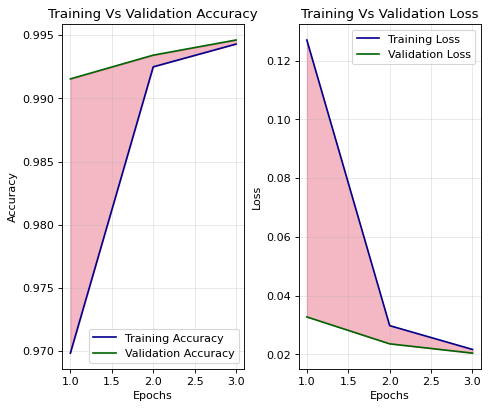

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(6, 5), dpi=80)

# Subplot 1: Training Vs Validation Accuracy
ax[0].plot(epochs, acc, label="Training Accuracy", color='darkblue')
ax[0].plot(epochs, val_acc, label="Validation Accuracy", color='darkgreen')
ax[0].grid(alpha=0.3)
ax[0].title.set_text('Training Vs Validation Accuracy')
ax[0].fill_between(epochs, acc, val_acc, color='crimson', alpha=0.3)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='lower right')  # Add legend here

# Subplot 2: Training Vs Validation Loss
ax[1].plot(epochs, loss, label="Training Loss", color='darkblue')
ax[1].plot(epochs, val_loss, label="Validation Loss", color='darkgreen')
ax[1].grid(alpha=0.3)
ax[1].title.set_text('Training Vs Validation Loss')
ax[1].fill_between(epochs, loss, val_loss, color='crimson', alpha=0.3)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='upper right')  # Add legend here

plt.show()

In [ ]:
import numpy as np
from seqeval.metrics import classification_report, f1_score
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

In [ ]:
def inspect_predictions(model, test_dataset, tokenizer, id2label, num_samples=5):
    for i, (inputs, _) in enumerate(test_dataset.take(num_samples)):
        predictions = model.predict(inputs)
        predicted_tag_indices = np.argmax(predictions, axis=-1)
        print(predicted_tag_indices)

        # Process a single batch from the dataset
        for j in range(len(inputs['input_ids'])):  # Iterate through each example in the batch
            input_ids_example = inputs['input_ids'][j].numpy()
            tokens = tokenizer.convert_ids_to_tokens(input_ids_example)
            predicted_tags = [id2label.get(idx, 'O') for idx in predicted_tag_indices[j]]

            print(f"Sample {i*num_samples + j + 1}:")
            print("Tokens\t\tPredicted Tags")
            print("-" * 30)
            for token, tag in zip(tokens, predicted_tags):
                if token == "[PAD]":  # Stop at padding
                    break
                print(f"{token}\t\t{tag}")
            print("\n" + "="*30 + "\n")

        if i >= num_samples - 1:  # Break after processing the desired number of samples
            break

In [ ]:
inspect_predictions(model, test_dataset, tokenizer, id2label, num_samples=5)

1/1 [==============================] - 4s 4s/step
[[ 0  2  0  2  2  2  3  4  4  2  3  2  2 29  3  4  2  3  4  4 31 27 31 32
  32  2 31  0  0  2 31 32 32  2  2 31  0  0  0  0  0  0  2 25 25  2  3  4
   4  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2 27 25  2 25  2
   2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
   2  2  0  0]
 [ 0  9  0  0  0  0  0  0  0  2  2 19 20 31 32  0  0 25 25 26  2  2  2 25
  26 26  2  2  2  2  2  2  0  2  2  2  2  2  2  2  2  2  2  2  2  2 11  0
   0  0  0  2  2  2  2  2  2  2  2  2 11  0  0  0  2  2  2  2  2  2 11  0
   0  0  2  2  2  2  2  2  2  2  2  2  2  2  0  0  0  2  2  0  0  0  0  0
   0  0  0  0]
 [ 0  2 11  0  0  0  2  2  2  2  0  2  2  2  2 25  2  3  0  3  0  0 31  0
   0 25 25 26  2  2  2 25 26 26  2  2  2  2  2 25 25  2  2  2  2  0  2  2
   2  2  2  2  2 25  2  2  2  2  2  2  2  5  0  0  0  0  0  2  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0]
 [ 0  2  2  0  0 

In [ ]:
import numpy as np

def evaluate_and_inspect(model, test_dataset, tokenizer, id2label, num_samples=5):
    # Counter to keep track of how many samples have been printed
    samples_printed = 0

    for inputs, labels in test_dataset.unbatch().batch(1):  # Ensure one example per batch
        true_labels = labels.numpy().squeeze(-1)  # Remove unnecessary dimensions
        predictions = model.predict(inputs)
        predicted_tag_indices = np.argmax(predictions, axis=-1)

        for i in range(true_labels.shape[0]):  # Loop through each example in the batch
            # true_seq_labels = [id2label[label] for label in true_labels[i] if label != 0]
            # predicted_seq_labels = [id2label[idx] for idx in predicted_tag_indices[i] if idx != 0]

            true_seq_labels = [id2label[label] for label in true_labels[i]]
            predicted_seq_labels = [id2label[idx] for idx in predicted_tag_indices[i]]

            # Printing a side-by-side comparison for a specified number of samples
            if samples_printed < num_samples:
                print(f"Sample {samples_printed + 1}:")
                print("Token\t\tTrue Label\tPredicted Label")
                print("-" * 50)

                tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][i].numpy())
                for token, true_label, pred_label in zip(tokens, true_seq_labels, predicted_seq_labels):
                    if token == "[PAD]":
                        break  # Stop printing after the last meaningful token
                    print(f"{token}\t\t{true_label}\t\t{pred_label}")
                print("\n" + "="*50 + "\n")
                samples_printed += 1

        # Break out of the loop once the specified number of samples have been printed
        if samples_printed >= num_samples:
            break

# Call the function to evaluate and inspect
evaluate_and_inspect(model, test_dataset, tokenizer, id2label, num_samples=5)


1/1 [==============================] - 0s 163ms/step
Sample 1:
Token		True Label	Predicted Label
--------------------------------------------------
<s>		UNK		UNK
Ġmod		O		O
_		UNK		UNK
proxy		UNK		UNK
Ġin		O		O
Ġhttpd		O		O
Ġin		O		O
ĠApache		B-vendor		B-vendor
ĠHTTP		B-application		B-application
ĠServer		I-application		I-application
Ġ2		B-version		B-version
.		UNK		UNK
2		UNK		UNK
.		UNK		UNK
9		UNK		UNK
Ġ,		O		O
Ġwhen		O		O
Ġrunning		O		O
Ġon		O		O
ĠUnix		O		O
Ġ,		O		O
Ġdoes		O		O
Ġnot		O		O
Ġclose		O		O
Ġthe		O		O
Ġbackend		O		O
Ġconnection		O		O
Ġif		O		O
Ġa		O		O
Ġtimeout		O		O
Ġoccurs		O		O
Ġwhen		O		O
Ġreading		O		O
Ġa		O		O
Ġresponse		O		O
Ġfrom		O		O
Ġa		O		O
Ġpersistent		O		O
Ġconnection		O		O
Ġ,		O		O
Ġwhich		O		O
Ġallows		B-relevantTerm		B-relevantTerm
Ġremote		B-relevantTerm		B-relevantTerm
Ġattackers		I-relevantTerm		I-relevantTerm
Ġto		O		O
Ġobtain		B-relevantTerm		B-relevantTerm
Ġa		O		O
Ġpotentially		B-relevantTerm		B-relevantTerm
Ġsensitive		I-relevantTerm		I-relevant

In [ ]:
true_labels_all = []
predicted_labels_all = []

for inputs, labels in test_dataset.unbatch().batch(1):
    true_labels = labels.numpy().squeeze(-1)
    #true_labels_batch = [[id2label[label] for label in seq_labels if label != 0] for seq_labels in true_labels]
    true_labels_batch = [[id2label[label] for label in seq_labels] for seq_labels in true_labels]
    true_labels_all.extend(true_labels_batch)

    predictions = model.predict(inputs)
    predicted_tag_indices = np.argmax(predictions, axis=-1)
    #predicted_labels_batch = [[id2label[idx] for idx in seq_pred if idx != 0] for seq_pred in predicted_tag_indices]
    predicted_labels_batch = [[id2label[idx] for idx in seq_pred] for seq_pred in predicted_tag_indices]
    predicted_labels_all.extend(predicted_labels_batch)

# Calculate and print out the classification report
print(classification_report(true_labels_all, predicted_labels_all))

# Print F1, Precision, and Recall scores
print("F1-Score: ", f1_score(true_labels_all, predicted_labels_all))
print("Precision: ", precision_score(true_labels_all, predicted_labels_all))
print("Recall: ", recall_score(true_labels_all, predicted_labels_all))

1/1 [==============================] - 0s 170ms/step


/usr/local/lib/python3.10/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: UNK seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


                     precision    recall  f1-score   support

                 NK       1.00      1.00      1.00     17977
        application       0.88      0.94      0.91      3329
              cveId       1.00      1.00      1.00       281
            edition       0.60      0.65      0.62        84
               file       0.95      1.00      0.97       459
           function       0.95      0.99      0.97       239
           hardware       0.68      0.39      0.49       137
             method       0.81      0.88      0.85        25
                 os       0.95      0.95      0.95       540
          parameter       0.95      0.99      0.97        93
programmingLanguage       0.93      1.00      0.97        14
       relevantTerm       1.00      1.00      1.00     11251
             update       0.96      0.90      0.93       694
             vendor       0.97      0.94      0.95      1611
            version       0.98      0.99      0.98      5852

          micro avg   

In [ ]:
# model_save_path = '/content/drive/MyDrive/datasets/DNRTI/bestModel/SecureBERT_RoBERTa_bilstm_att'
# model.save(model_save_path, save_format='tf')